In [1]:
!unzip -q /content/drive/MyDrive/Comys_Hackathon5.zip -d /content/Comys_Hackathon5

In [2]:
!sudo pip3 install keras
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import cv2
import os
import random
import shutil
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras import applications, models, layers, callbacks, optimizers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [3]:
train_dir = '/content/Comys_Hackathon5/Comys_Hackathon5/Task_B/train'
val_dir = '/content/Comys_Hackathon5/Comys_Hackathon5/Task_B/val'

train_image_count = sum([len(files) for r, d, files in os.walk(train_dir)])
val_image_count = sum([len(files) for r, d, files in os.walk(val_dir)])

print("Total images in train: {}".format(train_image_count))
print("Total images in val: {}".format(val_image_count))

Total images in train: 15408
Total images in val: 3376


In [8]:
def evaluate_model(model_path, test_data_path, img_size=(224, 224), batch_size=32):
    if not os.path.isdir(test_data_path):
        print(f"Error: Test data path not found or is not a directory: {test_data_path}")
        return None

    try:
        model = tf.keras.models.load_model(model_path)
        print(f"Model loaded successfully from {model_path}")
    except Exception as e:
        print(f"Error loading model from {model_path}: {e}")
        return None

    try:
        test_ds = tf.keras.utils.image_dataset_from_directory(
            test_data_path,
            labels='inferred',
            label_mode='binary',
            batch_size=batch_size,
            image_size=img_size,
            shuffle=False
        )
        normalization_layer = tf.keras.layers.Rescaling(1./255)
        test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

        AUTOTUNE = tf.data.AUTOTUNE
        test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

        print(f"Test dataset loaded from {test_data_path}")

    except Exception as e:
        print(f"Error loading test dataset from {test_data_path}: {e}")
        return None

    y_true = []
    y_pred_probs = model.predict(test_ds)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()

    for _, labels in test_ds.unbatch():
        y_true.append(int(labels.numpy().item()))

    y_true = np.array(y_true)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("\n--- Evaluation Metrics ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    print("\n--- Classification Report ---")
    target_names = ['Female', 'Male']
    print(classification_report(y_true, y_pred, target_names=target_names))

    metrics = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

    return metrics

model_file = "densenet169_gender_best.keras"
test_data_directory = "/content/Comys_Hackathon5/Comys_Hackathon5/Task_A/val"

if os.path.exists(model_file):
    evaluation_metrics = evaluate_model(model_file, test_data_directory)

    if evaluation_metrics:
        print("\nEvaluation Complete.")

else:
    print(f"Error: Model file not found at {model_file}")
    print("Please make sure the model path is correct.")

Model loaded successfully from densenet169_gender_best.keras
Found 422 files belonging to 2 classes.
Test dataset loaded from /content/Comys_Hackathon5/Comys_Hackathon5/Task_A/val
14/14 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step

--- Evaluation Metrics ---
Accuracy: 0.9171
Precision: 0.9325
Recall: 0.9590
F1-Score: 0.9456

--- Classification Report ---
              precision    recall  f1-score   support

      Female       0.86      0.79      0.83       105
        Male       0.93      0.96      0.95       317

    accuracy                           0.92       422
   macro avg       0.90      0.87      0.89       422
weighted avg       0.92      0.92      0.92       422


Evaluation Complete.


Model loaded successfully from densenet169_gender_best.keras


Saving formalpicture.jpeg to formalpicture.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step

Uploaded image: formalpicture.jpeg
Prediction: Male (Confidence: 0.9978)


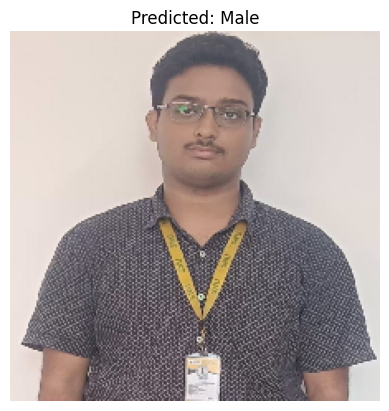

In [11]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def predict_image(model_path="densenet169_gender_best.keras", img_size=(224, 224)):

    try:
        model = tf.keras.models.load_model(model_path)
        print(f"Model loaded successfully from {model_path}")
    except Exception as e:
        print(f"Error loading model from {model_path}: {e}")
        return

    uploaded = files.upload()

    for fn in uploaded.keys():
        img_path = fn
        try:
            img = image.load_img(img_path, target_size=img_size)
            img_array = image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array /= 255.0

            predictions = model.predict(img_array)
            predicted_class = (predictions > 0.5).astype(int)[0][0]

            decoded_prediction = 'Male' if predicted_class == 1 else 'Female'
            confidence = predictions[0][0] if predicted_class == 1 else (1 - predictions[0][0])


            print(f"\nUploaded image: {fn}")
            print(f"Prediction: {decoded_prediction} (Confidence: {confidence:.4f})")


            plt.imshow(img)
            plt.title(f"Predicted: {decoded_prediction}")
            plt.axis('off')
            plt.show()
        except Exception as e:
            print(f"Error processing image {fn}: {e}")


predict_image()